In [1]:
import os
import numpy as np

In [18]:
# Define the directory where the processed L1 norm files are stored
base_dir = "/home/tersenov/CosmoGridV1/stage3_forecast/grid/"

# Collect all the expected L1 norm filenames
l1_norm_files = []
missing_files = []

In [ ]:
# Iterate over all cosmology and permutation directories
for cosmo_dir in sorted(os.listdir(base_dir)):
    cosmo_path = os.path.join(base_dir, cosmo_dir)
    
    if not os.path.isdir(cosmo_path):  # Skip non-directory files
        continue

    for perm_dir in sorted(os.listdir(cosmo_path)):
        perm_path = os.path.join(cosmo_path, perm_dir)
        
        if not os.path.isdir(perm_path):  # Skip non-directory files
            continue

        # Define the expected L1 norm file path
        file_path = os.path.join(perm_path, "projected_probes_maps_baryonified512_l1_norms_bin4_noisy_s0.26.npy")
        if os.path.exists(file_path):
            l1_norm_files.append(file_path)
        else:
            missing_files.append(file_path)  # Keep track of missing files

# Load all available L1 norm files
all_l1_norms = []
for file in l1_norm_files:
    data = np.load(file)  # Shape: (scales, bins)
    
    if len(data.shape) != 2:
        print(f"Skipping {file} due to unexpected shape {data.shape}")
        continue

    all_l1_norms.append(data)

# Convert list to numpy array with shape (realisations, scales, bins)
if all_l1_norms:
    all_l1_norms = np.stack(all_l1_norms, axis=0)  # Shape: (realisations, scales, bins)
    print(f"Loaded {len(l1_norm_files)} files successfully with shape {all_l1_norms.shape}.")
else:
    print("No valid L1 norm files found!")
    all_l1_norms = None

# Print missing files
if missing_files:
    print(f"Missing {len(missing_files)} files:")
    for missing in missing_files:
        print(missing)

In [ ]:
# # Save the combined array if needed
# np.save(os.path.join(base_dir, "all_l1_norms_bin2_nobaryons_noisy_s026.npy"), all_l1_norms)
# print(f"Saved concatenated L1 norms to: {base_dir}all_l1_norms_bin2_nobaryons_noisy_s026.npy")

Saved concatenated L1 norms to: /home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms_bin2_nobaryons_noisy_s026.npy


## Test

### Grid

In [18]:
all_l1_norms = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/new_grid/all_l1_norms_grid_nobaryons_bin4_noisy_s0.26_new_normalization.npy')

In [19]:
all_l1_norms.shape

(16965, 5, 40)

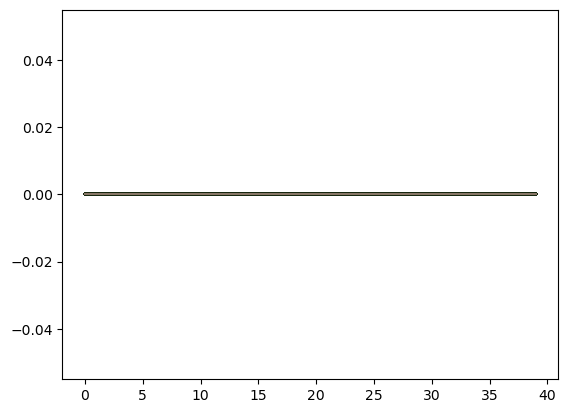

In [24]:
import matplotlib.pyplot as plt
for i in range(16965):
    plt.plot(all_l1_norms[i][4], alpha=0.1)

### Fiducial

In [5]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_l1_norms_fiducial_nobaryons_bin1_noisy_s0.26_new_normalization.npy', allow_pickle=True)

In [6]:
fid_mean = np.mean(fid_full, axis=0)
fid_mean.shape

(5, 40)

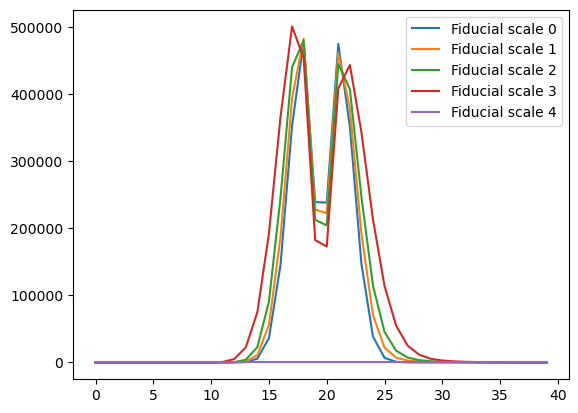

In [17]:
import matplotlib.pyplot as plt
for j in range(5):
    # for i in range(16965):
    #     plt.plot(all_l1_norms[i][3], alpha=0.1)
    plt.plot(fid_mean[j], label=f'Fiducial scale {j}', linestyle='-')
plt.legend()

### Test one-by-one

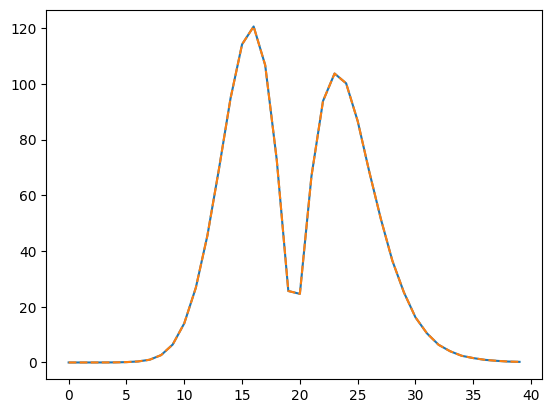

In [39]:
plt.plot(all_l1_norms[16965, 1, :], label='L1 Norm')
plt.plot(all_l1_norms_auto[16965, 1, :], label='L1 Norm Auto', linestyle='--')

## Fiducial

In [2]:
import os
import numpy as np

# Define the directory where the processed L1 norm files are stored
base_dir = "/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/"

# Collect all the expected L1 norm filenames
l1_norm_files = []
missing_files = []


In [67]:
all_l1_norms_bin1_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_l1_norms_fiducial_nobaryons_bin1_noisy_s0.26_new_normalization.npy', allow_pickle=True)
all_l1_norms_bin2_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_l1_norms_fiducial_nobaryons_bin2_noisy_s0.26_new_normalization.npy', allow_pickle=True)
all_l1_norms_bin3_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_l1_norms_fiducial_nobaryons_bin3_noisy_s0.26_new_normalization.npy', allow_pickle=True)
all_l1_norms_bin4_bnt = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_bnt_l1_norms_fiducial_nobaryons_bin4_noisy_s0.26_new_normalization.npy', allow_pickle=True)

In [68]:
all_l1_norms_bin1 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_nobaryons_bin1_noisy_s0.26_new_normalization.npy', allow_pickle=True)
all_l1_norms_bin2 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_nobaryons_bin2_noisy_s0.26_new_normalization.npy', allow_pickle=True)
all_l1_norms_bin3 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_nobaryons_bin3_noisy_s0.26_new_normalization.npy', allow_pickle=True)
all_l1_norms_bin4 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fiducial_nobaryons_bin4_noisy_s0.26_new_normalization.npy', allow_pickle=True)

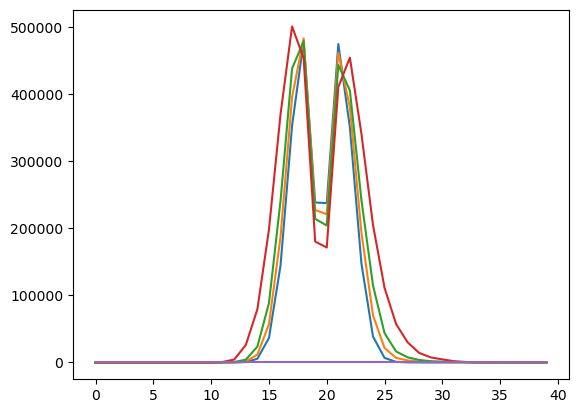

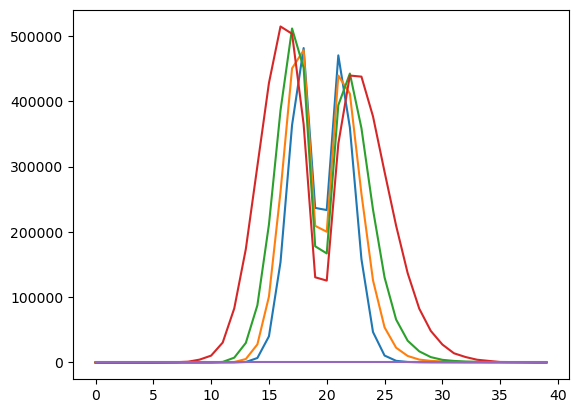

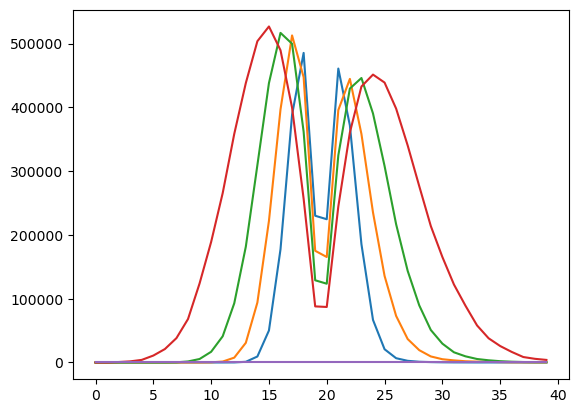

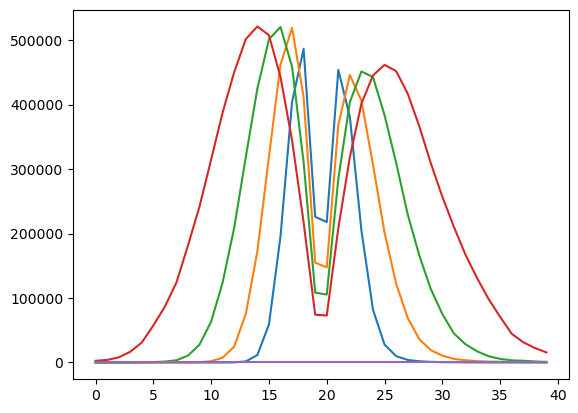

In [69]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.plot(all_l1_norms_bin1[11,i])
plt.show()

for i in range(5):
    plt.plot(all_l1_norms_bin2[11,i])
plt.show()

for i in range(5):
    plt.plot(all_l1_norms_bin3[11,i])
plt.show()

for i in range(5):
    plt.plot(all_l1_norms_bin4[11,i])
plt.show()

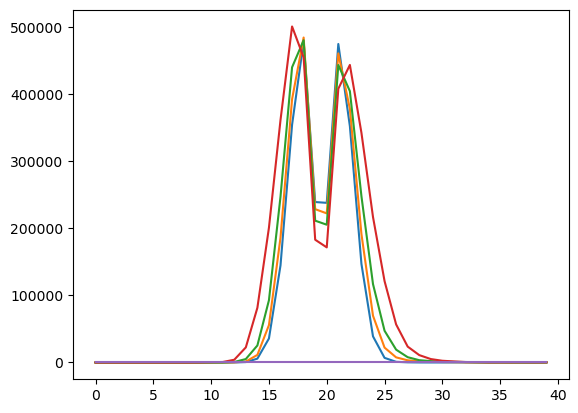

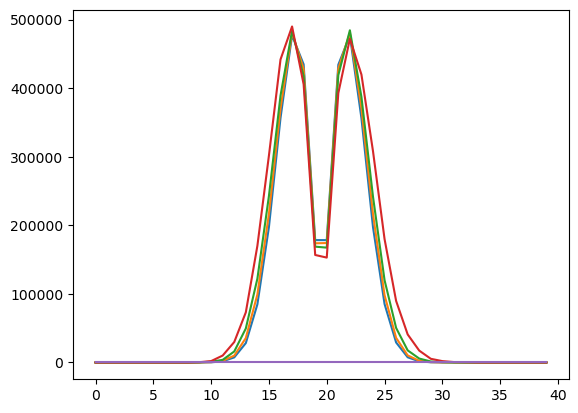

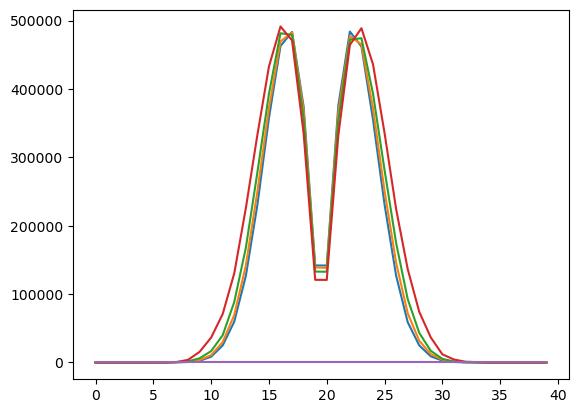

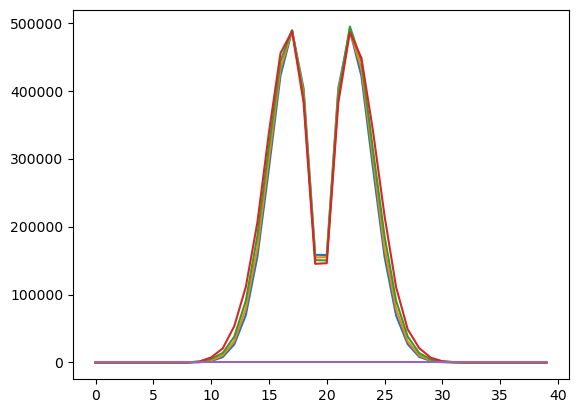

In [70]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.plot(all_l1_norms_bin1_bnt[11,i])
plt.show()

for i in range(5):
    plt.plot(all_l1_norms_bin2_bnt[11,i])
plt.show()

for i in range(5):
    plt.plot(all_l1_norms_bin3_bnt[11,i])
plt.show()

for i in range(5):
    plt.plot(all_l1_norms_bin4_bnt[11,i])
plt.show()

In [59]:
all_l1_norms_bin1.shape

(200, 5, 40)

In [61]:
all_l1_norms_bin1[11,1,8:200]

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 5.22833124e+00,
       1.66257116e+02, 1.43065582e+03, 1.12799328e+04, 5.56765489e+04,
       1.86075994e+05, 3.92202641e+05, 4.84196936e+05, 2.28450729e+05,
       2.22158210e+05, 4.60555693e+05, 3.77950964e+05, 1.91315216e+05,
       6.96604343e+04, 2.21548805e+04, 7.62500824e+03, 3.22910935e+03,
       1.71310281e+03, 9.31188656e+02, 6.49514706e+02, 4.66446816e+02,
       2.33330222e+02, 1.20866823e+02, 1.31327231e+02, 1.00813542e+02,
       1.09890618e+01, 9.06739346e+01, 8.38158877e+01, 5.10498845e+01])

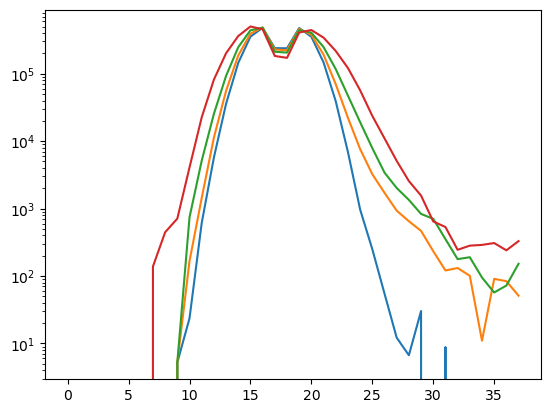

In [66]:
for i in range(5):
    plt.plot(all_l1_norms_bin1[11,i, 2:200])    
plt.yscale('log')
plt.show()

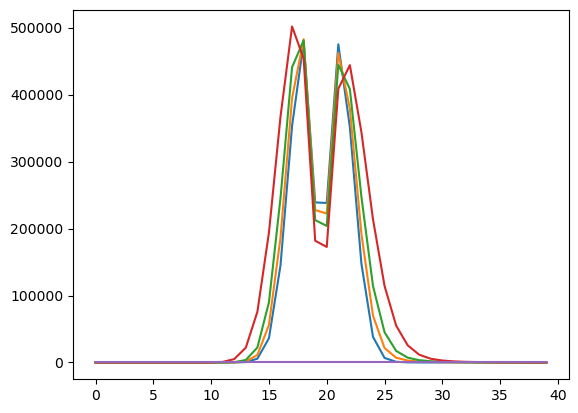

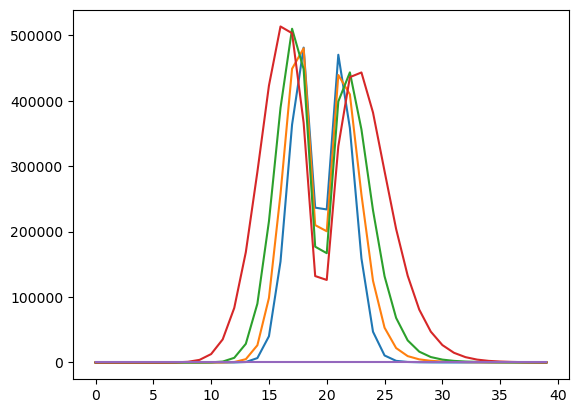

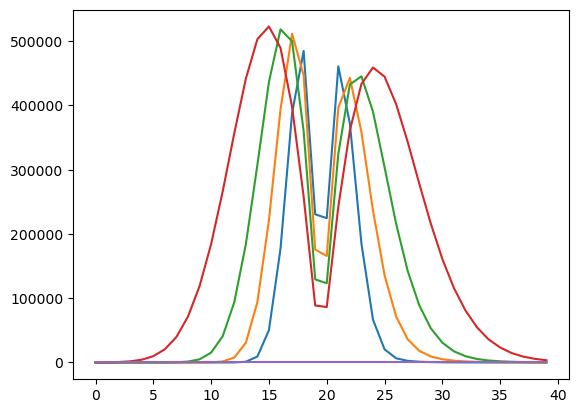

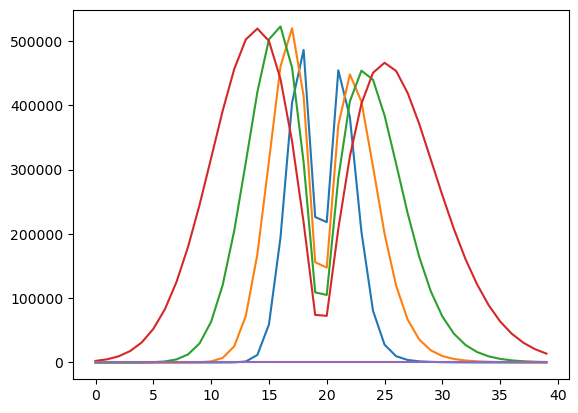

In [72]:
for i in range(5):
    plt.plot(all_l1_norms_bin1.mean(axis=0)[i])
plt.show()

for i in range(5):
    plt.plot(all_l1_norms_bin2.mean(axis=0)[i])
plt.show()

for i in range(5):
    plt.plot(all_l1_norms_bin3.mean(axis=0)[i])
plt.show()

for i in range(5):
    plt.plot(all_l1_norms_bin4.mean(axis=0)[i])
plt.show()

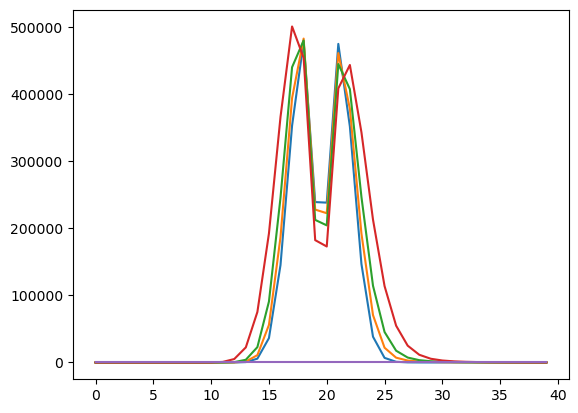

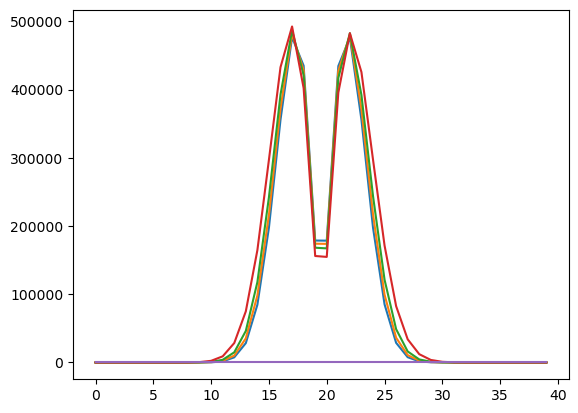

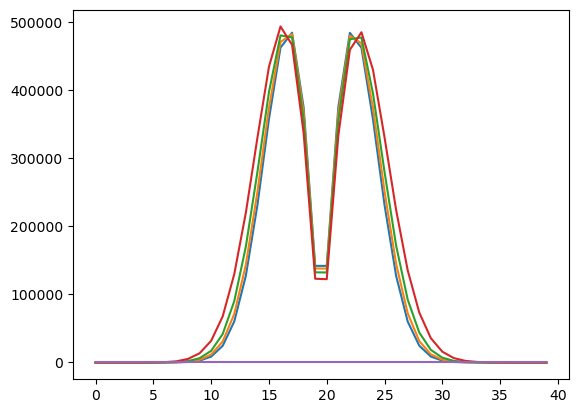

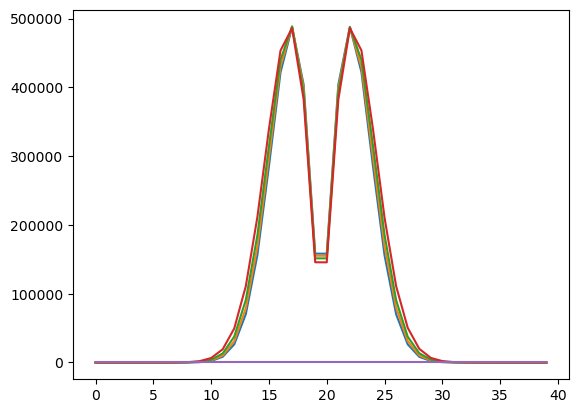

In [73]:
for i in range(5):
    plt.plot(all_l1_norms_bin1_bnt.mean(axis=0)[i])
plt.show()

for i in range(5):
    plt.plot(all_l1_norms_bin2_bnt.mean(axis=0)[i])
plt.show()

for i in range(5):
    plt.plot(all_l1_norms_bin3_bnt.mean(axis=0)[i])
plt.show()

for i in range(5):
    plt.plot(all_l1_norms_bin4_bnt.mean(axis=0)[i])
plt.show()